# **Radius Neighbors** 

## **Project:** 
-  Nearby Hospital Recommendation
## **Problem Statement:** 
   - Find hospitals within a specific distance radius for emergency situations.

In [1]:
# Step No 1 : Import required libraries

# Import Numerical library
import numpy as np 

# Import pandas library
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt 

# Import Seaborn Library 
import seaborn as sns

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# Import Radius Neighbors Classifier 
from sklearn.neighbors import RadiusNeighborsClassifier

# Import Evaluation metrics
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix



In [2]:
# Step No 2 : Load dataset
df = pd.read_csv("nearby_hospital_recommendation_dataset.csv")

In [3]:
# Step No 3 : Data understanding

# Display first rows 
print(df.head())

# Display statistical summary 
print(df.describe())

# Display dataset information
print(df.info())

   HospitalID HospitalName      City      HospitalType  DistanceKM  Rating  \
0           1   Hospital_1    Mumbai        Orthopedic        6.31     2.7   
1           2   Hospital_2    Nashik          Children       10.37     4.9   
2           3   Hospital_3  Kolhapur        Orthopedic        6.06     3.4   
3           4   Hospital_4    Mumbai  Multi-Speciality        2.58     3.9   
4           5   Hospital_5    Mumbai           General       13.87     3.7   

   AvailableBeds EmergencyAvailable  ConsultationFee  
0            283                Yes              464  
1            500                Yes              403  
2            456                Yes             1638  
3            362                Yes              592  
4            199                 No             1930  
        HospitalID   DistanceKM       Rating  AvailableBeds  ConsultationFee
count  1200.000000  1200.000000  1200.000000    1200.000000      1200.000000
mean    600.500000    12.342717     3.784083   

In [4]:
# Step No 4 : Data cleaning

# Check Missing Values 
print(df.isnull().sum())

# Check duplicate rows
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

HospitalID            0
HospitalName          0
City                  0
HospitalType          0
DistanceKM            0
Rating                0
AvailableBeds         0
EmergencyAvailable    0
ConsultationFee       0
dtype: int64
0


In [5]:
# Step No 5 : Encode target variable

# Convert Yes / No into Numeric Values 
df["EmergencyAvailable"] = df["EmergencyAvailable"].map({
    "Yes":1,
    "No": 0
})

In [6]:
# Step No 6 : Features and Target Splitting

# Define input features 
X = df[[
    "DistanceKM",
    "Rating",
    "AvailableBeds",
    "ConsultationFee"
]]

# Define target variable 
y = df["EmergencyAvailable"]

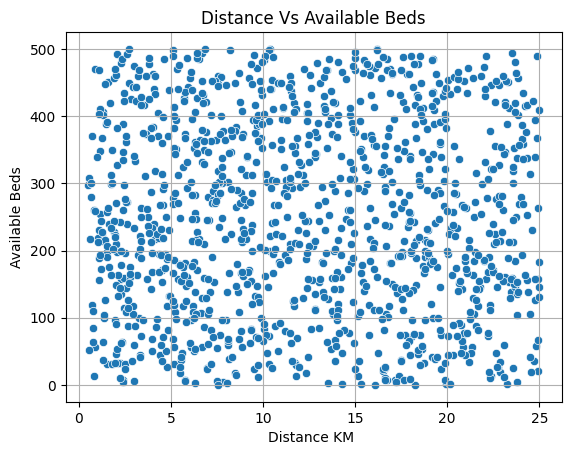

In [7]:
# Step No 7 : Visualization

# Create Scatter Plot 
sns.scatterplot(
    x = "DistanceKM",
    y = "AvailableBeds",
    data = df
)

# Set Plot title
plt.title("Distance Vs Available Beds")

# Set x- axis label 
plt.xlabel("Distance KM ")

# Set y - axis label 
plt.ylabel("Available Beds")

# Enable Grid 
plt.grid()

# Save figure 
plt.savefig("images/Distance vs Available Beds(RadiusNeighborsClassifier).png")

# Display the Plot 
plt.show()

In [8]:
# Step No 8 : Train Test Split

X_train , X_test , y_train , y_test = train_test_split(X , 
                                                       y , 
                                                       test_size=0.2,
                                                       random_state=42)

In [9]:
# Step No 9 : Feature Scaling
# Create Scaler Object 
scaler = StandardScaler()

# Fit and tranform train data 
X_train = scaler.fit_transform(X_train)

# Fit and Transform test data 
X_test = scaler.transform(X_test)

In [10]:
# Step No 10 : Initialize Radius Neighbors Model

model = RadiusNeighborsClassifier(
    radius=5.0,
    weights="distance",
    outlier_label=0
)

model.fit(X_train, y_train)

print(model)


# radius = search distance 
# weights = nearest hospitals get more importance 

RadiusNeighborsClassifier(outlier_label=0, radius=5.0, weights='distance')


In [11]:
# Step No 11 : Train model
model.fit(
    X_train,
    y_train
)

RadiusNeighborsClassifier(outlier_label=0, radius=5.0, weights='distance')

In [12]:
# Step No 12 : Prediction
y_pred = model.predict(
    X_test
)

# display predictions 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1]


In [13]:
# Step No 13 : Evaluation

# Calculate Accuaracy 
print("Accuaracy Score : ")
print(accuracy_score(y_test , y_pred))

# Calculate clasiffication Report 
print("Classification Report : ")
print(classification_report(y_test , y_pred ))

# Calculate Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

Accuaracy Score : 
0.4791666666666667
Classification Report : 
              precision    recall  f1-score   support

           0       0.47      0.06      0.11       124
           1       0.48      0.92      0.63       116

    accuracy                           0.48       240
   macro avg       0.48      0.49      0.37       240
weighted avg       0.48      0.48      0.36       240

Confusion Matrix : 
[[  8 116]
 [  9 107]]


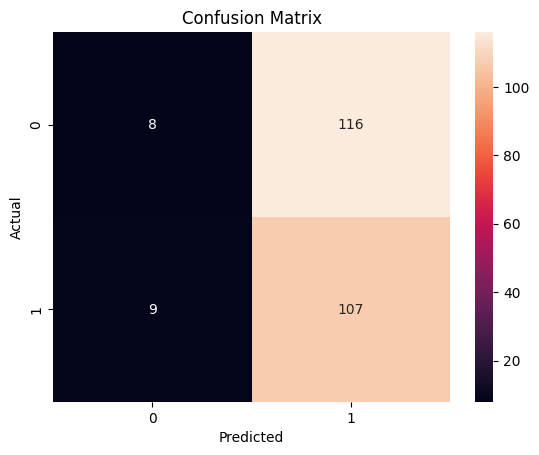

In [14]:
# Confusion Matrix Heatmap Visualization 
sns.heatmap(
    confusion_matrix(
        y_test,
        y_pred
    ),
    annot=True,
    fmt="d"
)


# Set Title 
plt.title("Confusion Matrix")

# Set x-axis label 
plt.xlabel("Predicted")

# Set y-axis label 
plt.ylabel("Actual")   

# Save figure 
plt.savefig("images/Confusion Matrix heatmap(RadiusNeighborsClassifier).png")

# Display Plot 
plt.show()         

In [15]:
# Step No 14 : User Input
# Take distance input 
distance = float(input("Enter Distance KM : "))

# Take Rating INput 
rating = float(input("Enter Hospital Rating : "))

# Take available beds input 
beds = int(input("Enter Availabel Beds : "))

# Take Consultation fee input 
fee = float(input("Enter consultation Fee : "))


In [16]:
# Step No 15 : Create User DataFrame
user_data = pd.DataFrame({
    "DistanceKM": [distance],
    "Rating": [rating],
    "AvailableBeds": [beds],
    "ConsultationFee": [fee]
})

In [17]:
# Step No 16 : Scale User Data input 
user_data = scaler.transform(
    user_data
)

In [18]:
# Step No 17 : Final Predict

# Predict Emergency availability
result = model.predict(user_data)

In [19]:
print(model)

RadiusNeighborsClassifier(outlier_label=0, radius=5.0, weights='distance')


In [20]:
# Step No 18 : Final Output

if result[0] == 1:
    print("Emergency Hospital Available")
else:
    print("Emergency Hospital Not Available")

Emergency Hospital Not Available
